In [91]:
"""Interspike interval statistics of a noisy integrate-and-fire neuron.

    du/dt = -alpha*u + Ibar + noise,   reset u -> 0 at u = 1

With subthreshold drive (Ibar below threshold) the neuron cannot fire
without noise at all, so every spike is noise-driven and the ISI
distribution is a first-passage density: sharply peaked with a long right
tail, nothing like the delta a deterministic model gives. Raising sigma
raises the firing rate even though the mean input has not changed, which
is the point of the model.

Two ways to collect ISIs, both here:
  - one long simulation, taking differences of spike times
  - many short first-passage runs, each stopped at threshold

The second gives a fixed sample size, so histograms are easier to compare
across parameters.

Uses lif_sim from lif_sim.py for the trace, rather than repeating the
integration loop as Noisy_IF.ipynb did twice more.

Fixed from the original: the first-passage loop wrote isi[j-1] instead of
isi[j], so entry 0 was never assigned and stayed exactly zero while entry
nsim-1 was written twice. One spurious zero interval in every sample
pulled the mean down and inflated the variance. The notebook also
demonstrated noise with rnd.rand() (uniform) where rnd.randn() (normal)
was meant.

Regression check: with Ibar = 0.95, sigma = 0.1 the two methods should
agree on the mean ISI to within sampling error. No ISI should be zero; if
one is, the off-by-one is back.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [80]:
def noisy_if(mu=0.95, sigma_sq=0.1, uth=1.0, dt=0.01, t_end=300, seed=0):
    rng = np.random.default_rng(seed)
    t_vals = np.linspace(0, t_end, int(t_end/dt)) 
    u_vals = np.zeros(len(t_vals))
    u_vals[0] = 0
    fire = 0
    
    for j in range(len(t_vals)-1):
        t = t_vals[j]
        u = u_vals[j]
        if u < uth:
            u += dt * (mu) + np.sqrt(2 * dt*sigma_sq) * rng.standard_normal()
            t += dt
        else:
            # reset, record the spike
            fire += 1
            u = 0
        u_vals[j+1] = u

    
    return t_vals, u_vals, fire


In [151]:
t_test, u_test, tot_fires = noisy_if(mu = 1, sigma_sq = .25, uth = 1, dt = .001, t_end = 500, seed = 10)
u_disc = u_test[50000:]

In [153]:
## find the theoretical probability of all of this
x_vals = np.linspace(min(u_disc),max(u_disc),1000)
def p(u, mu, theta, sigma_sq):
    if u > theta:
        return 0
    elif u >= 0:
        return (1 - np.e**(mu*(u - theta)/sigma_sq))/theta
    else:
        return (1 - np.e**(-1*mu*theta/sigma_sq))*np.e**(mu*u/sigma_sq)/theta

p_vals = [p(x, 1, 1, .25) for x in x_vals]
                        

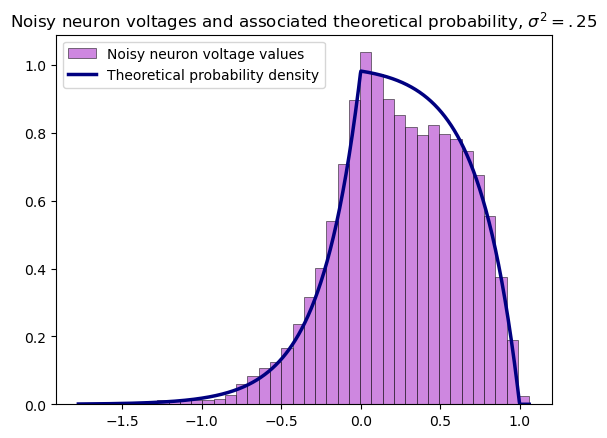

Total spikes in the whole time interval(500ms):  469
Firing rate 938.0 Hz
Percentage of time spent below u = 0:  0.27016444444444443


In [155]:
plt.hist(
    u_disc,
    bins=40,
    density=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    label="Noisy neuron voltage values",
    color = "mediumorchid"
)
plt.plot(x_vals, p_vals,
        linewidth = 2.5,
        color = "Navy",
        label = "Theoretical probability density")
plt.title(r"Noisy neuron voltages and associated theoretical probability, $\sigma^2 = .25$")
plt.legend()
plt.savefig("noisy_neuron_25.png", dpi = 300, bbox_inches = "tight")
plt.show()

# some diagnostics:
print("Total spikes in the whole time interval(500ms): ", tot_fires)
print("Firing rate", tot_fires/.5, "Hz")
print("Percentage of time spent below u = 0: ", np.mean(u_disc<0))

In [113]:
results = pd.DataFrame({
    "mu": [1, 1, 1],
    "theta": [1, 1, 1],
    "sigma_squared": [.25, 1, .4],
    "Measured Firing Rate(Hz)": [938, 882, 782],
    "Expected Firing Rate(Hz)": [1000, 1000, 1000],
    "Measured fraction of time below reset": [0.2702, 0.6455, 0.8979],
    "Expected fraction of time below reset": [0.2454, 0.6321, 0.8847]
})

results

,mu,theta,sigma_squared,Measured Firing Rate(Hz),Expected Firing Rate(Hz),Measured fraction of time below reset,Expected fraction of time below reset
0,1,1,0.25,938,1000,0.2702,0.2454
1,1,1,1.00,841,1000,0.6455,0.6321
2,1,1,0.40,782,1000,0.8979,0.8847
